In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import statsmodels.api as sm

from scipy.stats import linregress

import statistics as st

import functools as ft

In [2]:
path_name = '../data/co2_mm_mlo.csv'
mauna = pd.read_csv(path_name, comment='#')

In [3]:
print(mauna)


     year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0    1958      3     1958.2027   315.71          314.44     -1 -9.99 -0.99
1    1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2    1958      5     1958.3699   317.51          314.69     -1 -9.99 -0.99
3    1958      6     1958.4548   317.27          315.15     -1 -9.99 -0.99
4    1958      7     1958.5370   315.87          315.20     -1 -9.99 -0.99
..    ...    ...           ...      ...             ...    ...   ...   ...
813  2025     12     2025.9583   427.49          428.22     24  0.32  0.12
814  2026      1     2026.0417   428.62          428.34     25  0.69  0.27
815  2026      2     2026.1250   429.35          428.40     17  0.74  0.35
816  2026      3     2026.2083   430.15          428.72     26  0.86  0.32
817  2026      4     2026.2917   431.12          428.70     23  1.13  0.45

[818 rows x 8 columns]


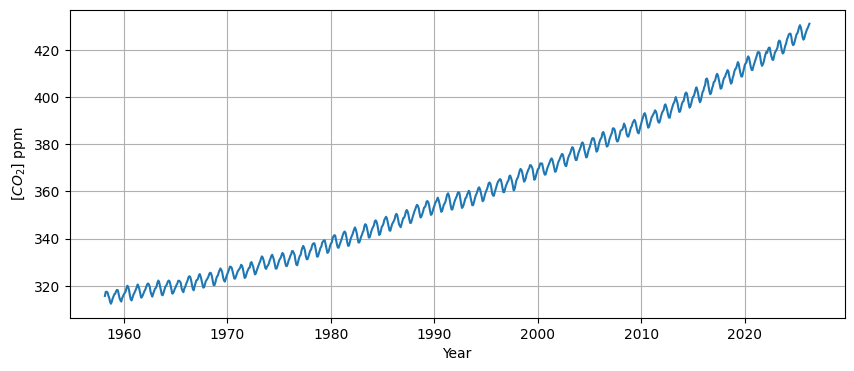

In [4]:
mauna["date"] = pd.to_datetime(
    dict(year=mauna["year"], month=mauna["month"], day=1)
)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(mauna["date"], mauna["average"])
plt.xlabel("Year")
plt.ylabel(r"[$CO_2$] ppm")
plt.grid(True)
plt.savefig("../img/keeling.pdf")
plt.show()

In [5]:
# Extract December values
mauna_dec = mauna.loc[mauna["month"] == 12, ["year", "average"]].copy()

# December of year N should be used as reference for year N+1
mauna_dec["year"] += 1
mauna_dec = mauna_dec.rename(columns={"average": "dec_average"})

# Merge with original dataframe
mauna_year = mauna.merge(mauna_dec, on="year", how="left")

# Increase relative to previous December
mauna_year["increase"] = mauna_year["average"] - mauna_year["dec_average"]

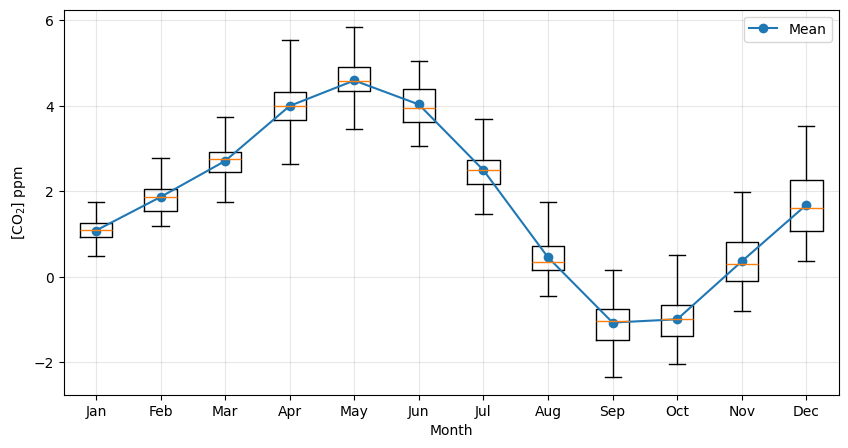

In [6]:
months = range(1, 13)

box_data = [
    mauna_year.loc[mauna_year["month"] == m, "increase"].dropna()
    for m in months
]

means = [
    mauna_year.loc[mauna_year["month"] == m, "increase"].mean()
    for m in months
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(box_data, positions=months, whis=(0, 100))
ax.plot(months, means, "o-", label="Mean")

ax.set_xticks(months)
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_xlabel("Month")

ax.set_ylabel(r"[CO$_2$] ppm")
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig("../img/yearly-variations.pdf")

plt.show()

In [7]:
path_name = '../data/Global_Carbon_Budget_2025_v0.6.csv'

fossil = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=",",
    dtype={"Year": "int64"}
)

fossil["Other"] = fossil[["Cement", "Flaring", "Other"]].sum(axis=1)

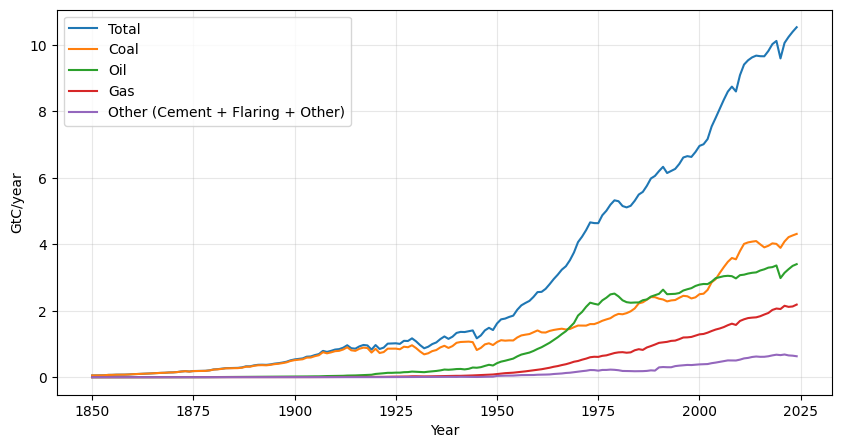

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(fossil["Year"], fossil["Total"], label="Total")
ax.plot(fossil["Year"], fossil["Coal"], label="Coal")
ax.plot(fossil["Year"], fossil["Oil"], label="Oil")
ax.plot(fossil["Year"], fossil["Gas"], label="Gas")
ax.plot(fossil["Year"], fossil["Other"], label="Other (Cement + Flaring + Other)")

ax.set_xlabel("Year")
ax.set_ylabel("GtC/year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../img/gcb.pdf")
plt.show()

In [9]:
sorted = fossil.sort_values("Year")

cols = ["Total", "Coal", "Oil", "Gas", "Other"]

cum = sorted.copy()
cum[cols] = cum[cols].cumsum()

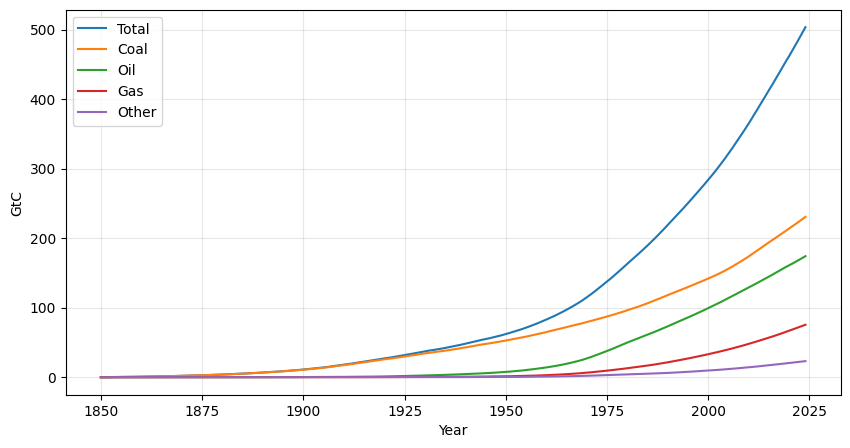

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for c in cols:
    ax.plot(cum["Year"], cum[c], label=c)

ax.set_xlabel("Year")
ax.set_ylabel("GtC")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../img/gcb-cum.pdf")
plt.show()

In [11]:
cum[cum["Year"] == 1958]

,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Capita
108,1958,77.94244,62.21497,12.435137,2.507049,0.035397,0.025959,0.785283,0.000789


In [12]:
fossil[fossil["Year"] == 2024]

,Year,Total,Coal,Oil,Gas,Cement,Flaring,Other,Capita
174,2024,10.534546,4.313661,3.403547,2.186088,0.40197,0.113457,0.63125,0.001291


In [13]:
atm = mauna.loc[mauna["month"] == 12, ["year", "average"]].copy()

atm["incr"] = atm["average"].diff()
atm = atm.loc[(atm["year"] >= 1959) & (atm["year"] <= 2024),
              ["year", "incr"]].reset_index(drop="True")

fos = fossil.loc[
    (fossil["Year"] >= 1959) &
    (fossil["Year"] <= 2024),
    ["Year", "Total"]
].copy()

fos = fos.rename(columns={
    "Year": "year",
    "Total": "emi"
})

# Convert GtC to ppm
fos["emi"] = fos["emi"] / 2.13



In [14]:
atm

,year,incr
0,1959,0.91
1,1960,0.61
2,1961,0.82
3,1962,0.69
4,1963,0.65
...,...,...
61,2020,2.26
62,2021,2.44
63,2022,2.32
64,2023,2.87


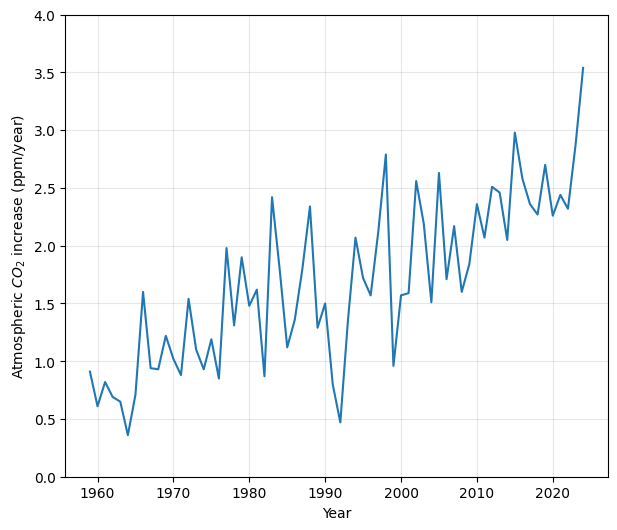

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))


ax.plot(
    atm['year'],
    atm['incr']
)

ax.set_ylim(0.0,4.0)
ax.set_xlabel("Year")
ax.set_ylabel(r"Atmospheric $CO_2$ increase (ppm/year)")

ax.grid(True, alpha=0.3)

plt.savefig("../img/increase.pdf")

plt.show()

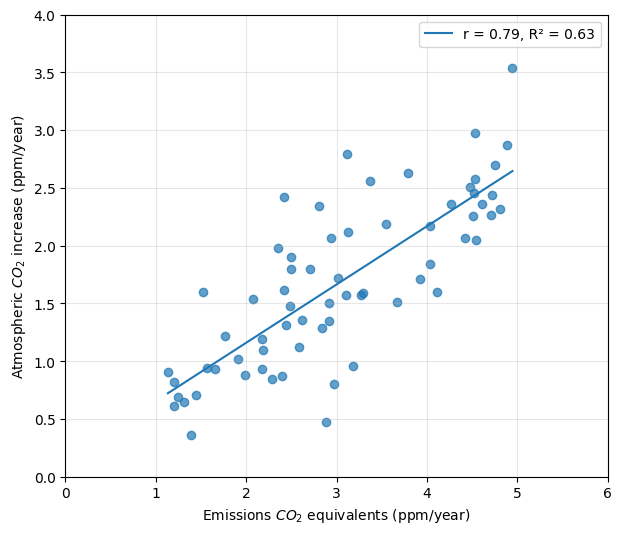

In [16]:
x = fos["emi"]
y = atm["incr"]

res = linregress(x, y)

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter
ax.scatter(x, y, alpha=0.7)

# Regression line
xfit = np.linspace(x.min(), x.max(), 100)
yfit = res.intercept + res.slope * xfit

ax.plot(
    xfit,
    yfit,
    label=f"r = {res.rvalue:.2f}, R² = {res.rvalue**2:.2f}"
)

ax.set_xlim(0.0, 6.0)
ax.set_ylim(0.0,4.0)
ax.set_xlabel("Emissions $CO_2$ equivalents (ppm/year)")
ax.set_ylabel(r"Atmospheric $CO_2$ increase (ppm/year)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig("../img/correlation.pdf")

plt.show()

In [17]:
path_name = '../data/uahncdc_lt_6.1.csv'

uah = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=".",
    dtype={"Year": "int64", "Mo": "int64"}
)

uah["Date"] = pd.to_datetime(dict(year=uah["Year"], month=uah["Mo"], day=1))

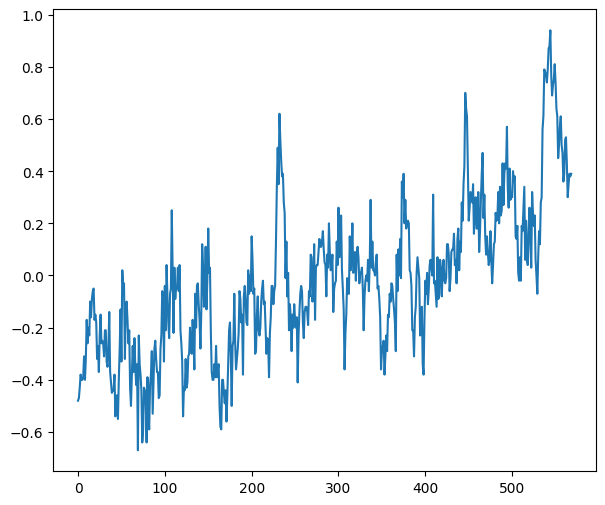

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))



plt.plot(uah["Globe"])

In [19]:
uah

,Year,Mo,Globe,Land,Ocean,NH,Land.1,Ocean.1,SH,Land.2,...,Land.6,Ocean.6,SoPol,Land.7,Ocean.7,USA48,USA49,AUST,CANADA,Date
0,1978,12,-0.48,-0.52,-0.46,-0.44,-0.47,-0.42,-0.52,-0.62,...,-0.68,-0.06,-0.45,-0.37,-0.49,-1.29,-1.15,-1.30,-0.95,1978-12-01
1,1979,1,-0.47,-0.64,-0.41,-0.64,-0.86,-0.50,-0.31,-0.13,...,-0.95,0.10,-0.15,-0.15,-0.16,-3.22,-2.42,0.92,-0.32,1979-01-01
2,1979,2,-0.43,-0.56,-0.38,-0.47,-0.57,-0.41,-0.39,-0.53,...,-2.30,-1.66,-0.80,-1.25,-0.58,-1.76,-1.84,-0.30,-3.99,1979-02-01
3,1979,3,-0.38,-0.52,-0.33,-0.46,-0.51,-0.44,-0.30,-0.53,...,-0.47,-0.65,-0.52,-1.25,-0.18,-0.70,-0.39,0.22,0.37,1979-03-01
4,1979,4,-0.40,-0.57,-0.34,-0.47,-0.62,-0.37,-0.34,-0.46,...,-0.81,-0.87,-0.26,0.26,-0.51,-0.73,-0.46,-1.12,-0.35,1979-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2025,12,0.30,0.52,0.22,0.45,0.56,0.38,0.15,0.42,...,-0.17,0.88,0.28,0.67,0.10,2.10,1.77,0.37,-1.86,2025-12-01
565,2026,1,0.35,0.61,0.25,0.51,0.67,0.41,0.19,0.48,...,1.39,1.41,0.20,0.54,0.04,0.30,0.49,0.95,1.17,2026-01-01
566,2026,2,0.39,0.93,0.17,0.54,1.14,0.16,0.23,0.44,...,-0.35,-0.62,0.60,0.88,0.47,1.91,1.58,0.73,0.32,2026-02-01
567,2026,3,0.38,0.64,0.28,0.33,0.63,0.14,0.42,0.65,...,-0.62,-0.32,0.75,0.92,0.68,3.74,2.62,1.14,-3.17,2026-03-01


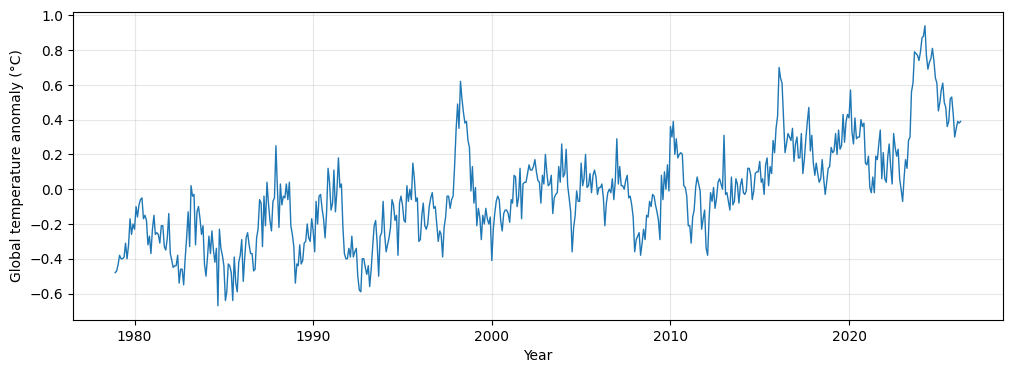

In [20]:
uah = uah.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 4))


ax.plot(uah["Date"], uah["Globe"], linewidth=1)

ax.set_ylabel("Global temperature anomaly (°C)")
ax.set_xlabel("Year")
ax.grid(True, alpha=0.3)

In [21]:
path_name = '../data/noaa.csv'

noaa = pd.read_csv( path_name,
    comment="#",
    sep=";",
    decimal=".",
    dtype={"Year": "int64", "Month": "int64"}
)

noaa["Date"] = pd.to_datetime(dict(year=noaa["Year"], month=noaa["Month"], day=1))

In [22]:
print(noaa)

     Year  Month  Anom       Date
0    1958      1  0.36 1958-01-01
1    1958      2  0.20 1958-02-01
2    1958      3  0.15 1958-03-01
3    1958      4  0.07 1958-04-01
4    1958      5  0.09 1958-05-01
..    ...    ...   ...        ...
799  2024      8  1.24 2024-08-01
800  2024      9  1.22 2024-09-01
801  2024     10  1.31 2024-10-01
802  2024     11  1.30 2024-11-01
803  2024     12  1.26 2024-12-01

[804 rows x 4 columns]


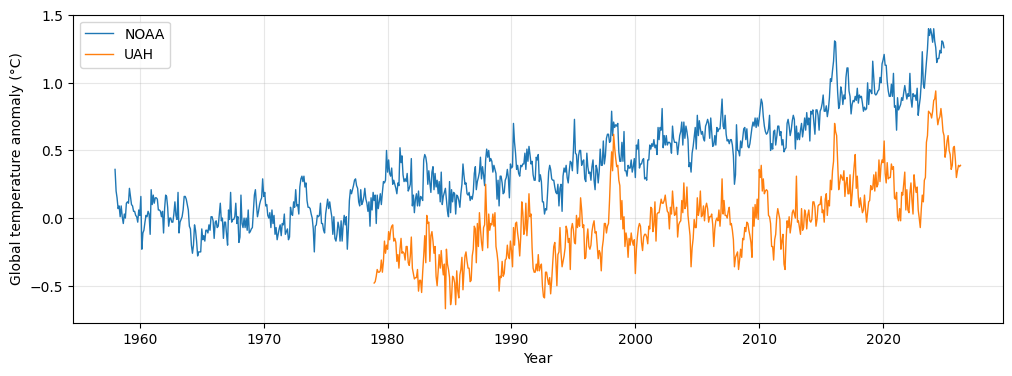

In [23]:
noaa = noaa.sort_values("Date")

fig, ax = plt.subplots(figsize=(12, 4))


ax.plot(noaa["Date"], noaa["Anom"], linewidth=1, label="NOAA")
ax.plot(uah["Date"], uah["Globe"], linewidth=1, label="UAH")

ax.set_ylabel("Global temperature anomaly (°C)")
ax.set_xlabel("Year")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("../img/temperature.pdf")

Slope      = 1.960
Intercept  = 2.043
r          = 0.801
R²         = 0.642
p-value    = 2.285e-11


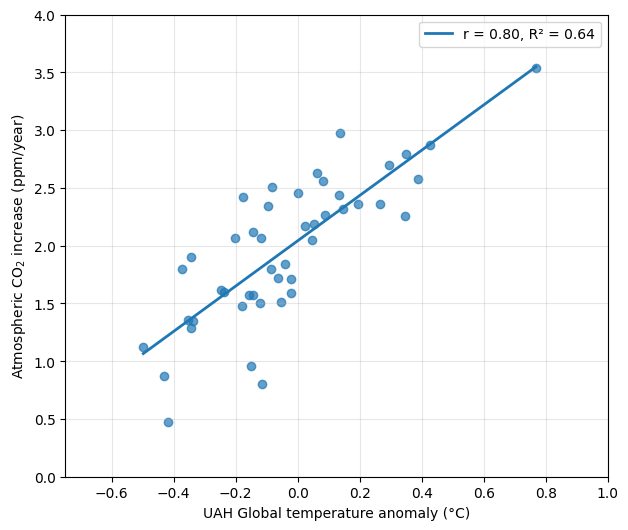

In [24]:
uah_year = (
    uah.loc[(uah["Year"] >= 1979) & (uah["Year"] <= 2024)]
       .groupby("Year")["Globe"]
       .mean()
       .reset_index()
       .rename(columns={"Year": "year", "Globe": "temp"})
       
)

x = uah_year["temp"]
y = atm.loc[(atm["year"] >= 1979) & (atm["year"] <= 2024)].reset_index(drop="True")["incr"]




res = linregress(x, y)

print(f"Slope      = {res.slope:.3f}")
print(f"Intercept  = {res.intercept:.3f}")
print(f"r          = {res.rvalue:.3f}")
print(f"R²         = {res.rvalue**2:.3f}")
print(f"p-value    = {res.pvalue:.3e}")

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter points
ax.scatter(x, y, alpha=0.7)

# Regression line
xx = np.linspace(x.min(), x.max(), 100)
yy = res.intercept + res.slope * xx

ax.plot(
    xx,
    yy,
    linewidth=2,
    label=f"r = {res.rvalue:.2f}, R² = {res.rvalue**2:.2f}"
)
ax.set_xlim(-0.75,1)
ax.set_ylim(0,4)
ax.set_ylabel(r"Atmospheric CO$_2$ increase (ppm/year)")
ax.set_xlabel("UAH Global temperature anomaly (°C)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

Slope      = 1.751
Intercept  = 0.986
r          = 0.847
R²         = 0.717
p-value    = 3.483e-19


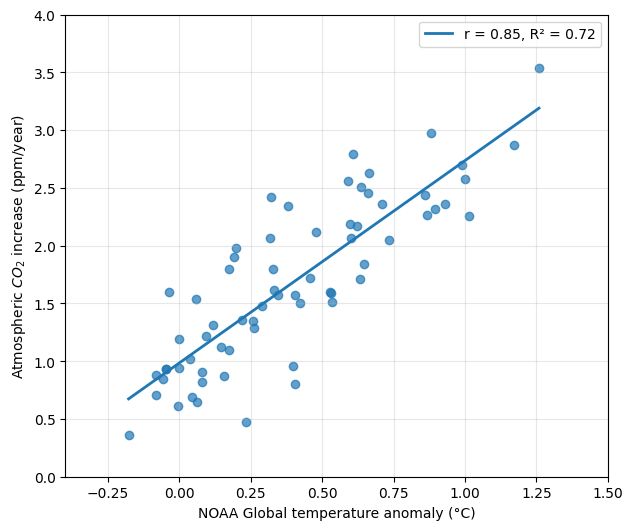

In [25]:
noaa_year = (
    noaa.loc[(noaa["Year"] >= 1959) & (noaa["Year"] <= 2024)]
    .groupby("Year")["Anom"]
    .mean()
    .reset_index()
    .rename(columns={"Year": "year", "Anom": "temp"})
)

x = noaa_year["temp"]
y = atm.loc[(atm["year"] >= 1959) & (atm["year"] <= 2024)].reset_index(drop="True")["incr"]



res = linregress(x, y)

print(f"Slope      = {res.slope:.3f}")
print(f"Intercept  = {res.intercept:.3f}")
print(f"r          = {res.rvalue:.3f}")
print(f"R²         = {res.rvalue**2:.3f}")
print(f"p-value    = {res.pvalue:.3e}")

fig, ax = plt.subplots(figsize=(7, 6))

# Scatter points
ax.scatter(x, y, alpha=0.7)

# Regression line
xx = np.linspace(x.min(), x.max(), 100)
yy = res.intercept + res.slope * xx

ax.plot(
    xx,
    yy,
    linewidth=2,
    label=f"r = {res.rvalue:.2f}, R² = {res.rvalue**2:.2f}"
)
ax.set_xlim(-0.4, 1.5)
ax.set_ylim(0,4)
ax.set_ylabel(r"Atmospheric $CO_2$ increase (ppm/year)")
ax.set_xlabel("NOAA Global temperature anomaly (°C)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.savefig("../img/temperature-ppm.pdf")
plt.show()

In [26]:
temp = noaa_year

In [27]:
df = (
    atm
    .merge(temp, on="year")
    .merge(fos, on="year")
)
X = df[["temp", "emi"]]
X = sm.add_constant(X)   # adds intercept

y = df["incr"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   incr   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     79.67
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           5.60e-18
Time:                        15:57:44   Log-Likelihood:                -29.514
No. Observations:                  66   AIC:                             65.03
Df Residuals:                      63   BIC:                             71.60
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0013      0.238      4.198      0.0

In [28]:
print(df[["incr", "temp", "emi"]].corr())


          incr      temp       emi
incr  1.000000  0.846543  0.794221
temp  0.846543  1.000000  0.939989
emi   0.794221  0.939989  1.000000


In [29]:
atm

,year,incr
0,1959,0.91
1,1960,0.61
2,1961,0.82
3,1962,0.69
4,1963,0.65
...,...,...
61,2020,2.26
62,2021,2.44
63,2022,2.32
64,2023,2.87


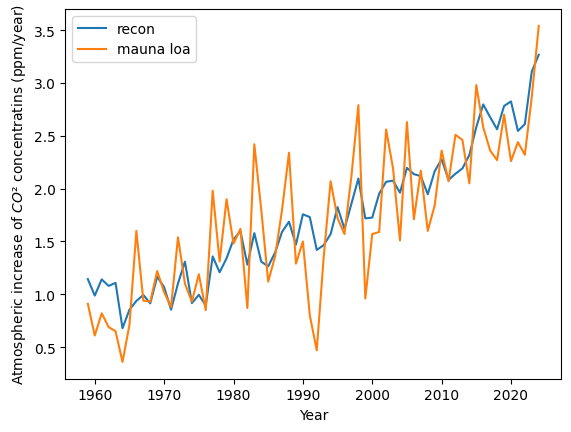

In [34]:
recon1 = temp.copy()

# Predicted annual increase
recon1["incr"] = 1.8 * recon1["temp"] + 1

plt.plot(recon1["year"], recon1["incr"], label="recon")
plt.plot(atm["year"], atm["incr"], label="mauna loa")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric increase of $CO²$ concentratins (ppm/year)")
plt.legend()
plt.savefig("../img/recon1.pdf")

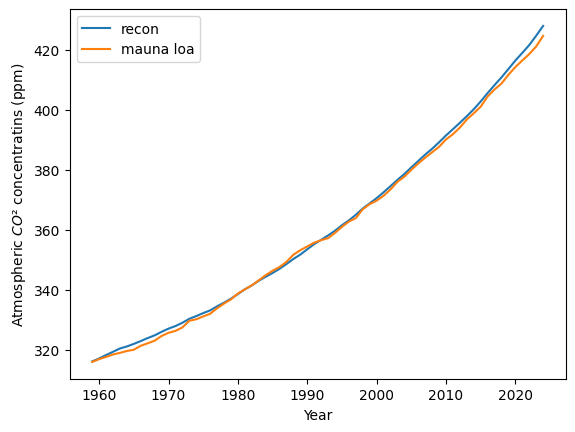

In [35]:
recon2 = temp.copy()

# Predicted annual increase
recon2["incr"] = 1.8 * recon2["temp"] + 1.0

# Reconstructed concentration
recon2["co2"] = 315.0 + recon2["incr"].cumsum()

plt.plot(recon2["year"], recon2["co2"], label="recon")
plt.plot(mauna.loc[(mauna["year"] >= 1959) & (mauna["year"] <= 2024)].groupby("year").mean()["average"], label="mauna loa")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric $CO²$ concentratins (ppm)")
plt.legend()
plt.savefig("../img/recon2.pdf")

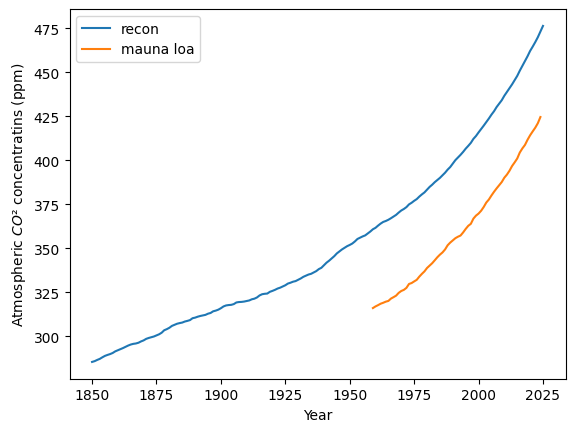

In [36]:
path_name = '../data/noaa2.csv'

noaa2 = pd.read_csv( path_name,
    comment="#",
    sep=",",
    decimal=".",
    dtype={"year": "int64"}
)



recon3 = noaa2.copy()

# Predicted annual increase
recon3["incr"] = 1.8 * recon3["anom"] + 1

# Reconstructed concentration
recon3["co2"] = 285.0 + recon3["incr"].cumsum()

plt.plot(recon3["year"], recon3["co2"], label="recon")
plt.plot(mauna.loc[(mauna["year"] >= 1959) & (mauna["year"] <= 2024)].groupby("year").mean()["average"], label="mauna loa")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric $CO²$ concentratins (ppm)")
plt.legend()
plt.savefig("../img/recon3.pdf")



In [74]:
temp = uah.loc[(uah["Year"] >= 1979) & (uah["Year"] <= 2025)].rename(columns={"Year": "year", "Globe": "temp"})


temp = temp.groupby("year").mean()

atm = mauna.loc[mauna["month"] == 12, ["year", "average"]].copy()

atm["incr"] = atm["average"].diff()
atm = atm.loc[(atm["year"] >= 1979) & (atm["year"] <= 2025),
              ["year", "incr"]].reset_index(drop="True")




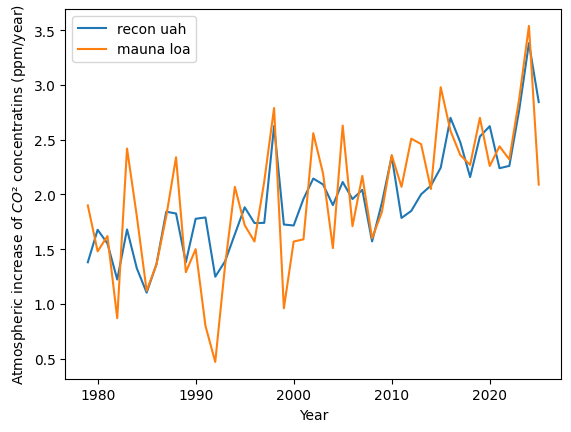

In [94]:
recon4 = temp.copy()

# Predicted annual increase
recon4["incr"] = 1.8 * recon4["temp"] + 2.0

plt.plot(recon4["incr"], label="recon uah")
plt.plot(atm["year"], atm["incr"], label="mauna loa")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric increase of $CO²$ concentratins (ppm/year)")
plt.legend()
plt.savefig("../img/recon4.pdf")

In [93]:
res = linregress(temp["temp"], atm["incr"])

print(f"Slope      = {res.slope:.3f}")
print(f"Intercept  = {res.intercept:.3f}")
print(f"r          = {res.rvalue:.3f}")
print(f"R²         = {res.rvalue**2:.3f}")
print(f"p-value    = {res.pvalue:.3e}")

Slope      = 1.826
Intercept  = 2.021
r          = 0.777
R²         = 0.604
p-value    = 1.355e-10


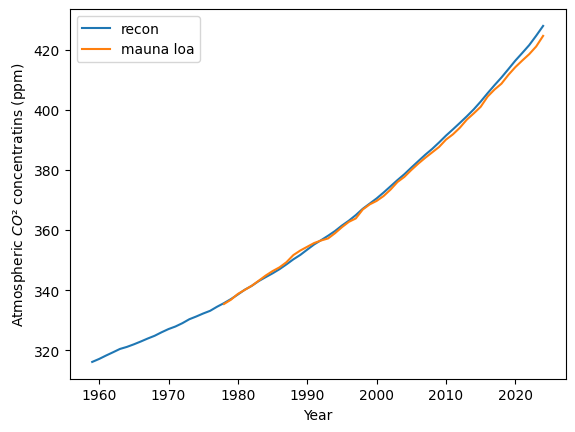

In [95]:
recon5 = temp.copy()

# Predicted annual increase
recon5["incr"] = 1.8 * recon5["temp"] + 1.0

# Reconstructed concentration
recon5["co2"] = 334.0 + recon5["incr"].cumsum()

plt.plot(recon2["year"], recon2["co2"], label="recon")
plt.plot(mauna.loc[(mauna["year"] >= 1978) & (mauna["year"] <= 2024)].groupby("year").mean()["average"], label="mauna loa")
plt.xlabel("Year")
plt.ylabel(r"Atmospheric $CO²$ concentratins (ppm)")
plt.legend()
plt.savefig("../img/recon5.pdf")